# CIFAR10

## nn.Sequential --> fonction

## nn.Dropout --> couche

In [61]:
import os

import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from torch.utils.tensorboard import SummaryWriter
import torchvision.transforms as transforms
import torchmetrics

torch.cuda.is_available()

True

In [62]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device :", device)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

Device : cuda
True
NVIDIA GeForce RTX 3070 Laptop GPU


In [63]:
from torchvision.transforms import ToTensor

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

dataset_train = torchvision.datasets.CIFAR10(
    root='./data_cifar_10',
    train= True,
    transform=transform,
    download=True,
)
dataset_test = torchvision.datasets.CIFAR10(
    root='./data_cifar_10',
    train= False,
    transform=transform,
    download=True,
)

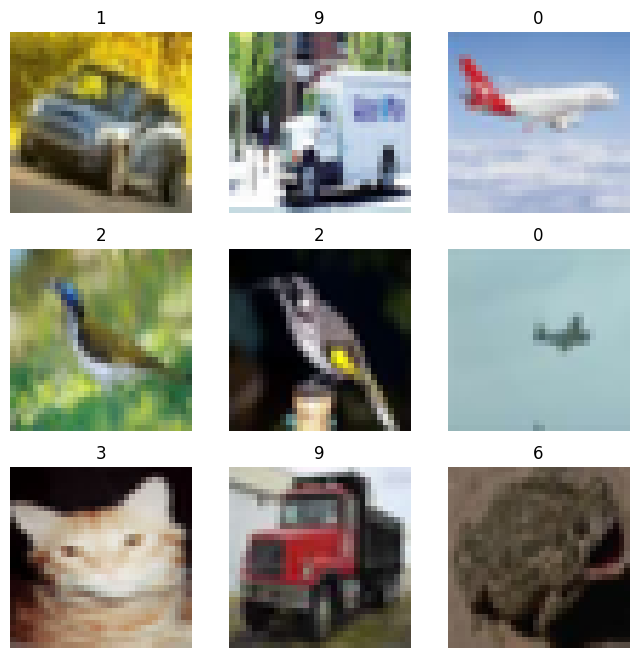

In [64]:
mean = torch.tensor(imagenet_mean).view(3, 1, 1)
std  = torch.tensor(imagenet_std).view(3, 1, 1)

figure = plt.figure(figsize=(8,8))
cols, rows = 3, 3
for i in range(1, cols*rows+1):
    sample_idx = torch.randint(len(dataset_train), size=(1,)).item()
    img, label = dataset_train[sample_idx]
    img = (img * std + mean).clamp(0, 1)
    figure.add_subplot(rows, cols, i)
    plt.title(label)
    plt.axis("off")
    plt.imshow(img.permute(1, 2, 0))
plt.show()

In [65]:
from torch.utils.data import DataLoader

dataloader_train = DataLoader(dataset_train, batch_size=64, shuffle=True)
dataloader_test = DataLoader(dataset_test, batch_size=64, shuffle=False)

In [66]:
train_features, train_labels = next(iter(dataloader_train))
train_features.size()

torch.Size([64, 3, 32, 32])

In [67]:
from torch import nn

def forward():
    features = nn.Sequential(
        nn.Conv2d(3, 32, kernel_size=3, padding=1),
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.MaxPool2d(2),
        nn.Conv2d(32, 64, kernel_size=3, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(2),
        nn.Conv2d(64, 128, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.AdaptiveAvgPool2d((1, 1))
    )

    classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(128, 128),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(64, 10)
    )

    return nn.Sequential(features, classifier)


In [68]:
mlp = forward().to(device)

print(mlp)

n_params = sum(p.numel() for p in mlp.parameters() if p.requires_grad)
print(f"\n[2.3] Paramètres entraînables : {n_params:,}")

Sequential(
  (0): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU()
    (10): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (1): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=128, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.

In [69]:
# x_dummy = torch.randn(1, 3, 32, 32)
# output = mlp(x_dummy)
# print(f"\n[2.4] Forward pass : entrée {x_dummy.shape} --> {output.shape}")
# print(f"Sortie : {output}")

In [70]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(mlp.parameters(), lr=1e-3)

In [71]:
log_dir = os.path.join("runs", "atelier4")
writer = SummaryWriter(log_dir=log_dir)

history = {
    "epoch": [],
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": [],
    "batch_step": [],
    "batch_loss": [],
    "batch_acc": [],
}

global_step = 0

In [72]:
def train_loop(dataloader, model, loss_fn, optimizer, writer=None, history=None, global_step=0):
    size = len(dataloader.dataset)
    model.train()
    num_batches = len(dataloader)
    running_loss = 0.0
    running_correct = 0
    loop = tqdm(enumerate(dataloader), total=num_batches, desc="Train", leave=False)
    for batch, (X, y_true) in loop:
        X = X.to(device)
        y_true = y_true.to(device)
        
        y_pred = model(X)
        loss = loss_fn(y_pred, y_true)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        batch_loss = loss.item()
        batch_correct = (y_pred.argmax(1) == y_true).sum().item()
        batch_acc = batch_correct / X.size(0)
        running_loss += batch_loss
        running_correct += batch_correct

        if writer is not None:
            writer.add_scalar("Batch/Loss", batch_loss, global_step)
            writer.add_scalar("Batch/Accuracy", batch_acc, global_step)
        if history is not None:
            history["batch_step"].append(global_step)
            history["batch_loss"].append(batch_loss)
            history["batch_acc"].append(batch_acc)

        # Met à jour la barre et affiche la perte actuelle
        current = batch * getattr(dataloader, 'batch_size', X.size(0)) + X.size(0)
        loop.set_postfix({'loss': f"{batch_loss:.4f}", 'samples': f"{current}/{size}"})
        global_step += 1

    avg_loss = running_loss / num_batches
    accuracy = running_correct / size
    return avg_loss, accuracy, global_step


def test_loop(dataloader, model, loss_fn, num_classes=10):
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    accuracy  = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes).to(device)
    precision = torchmetrics.Precision(task="multiclass", num_classes=num_classes, average="macro").to(device)
    recall    = torchmetrics.Recall(task="multiclass", num_classes=num_classes, average="macro").to(device)
    f1        = torchmetrics.F1Score(task="multiclass", num_classes=num_classes, average="macro").to(device)
    confmat   = torchmetrics.ConfusionMatrix(task="multiclass", num_classes=num_classes).to(device)

    loop = tqdm(enumerate(dataloader), total=num_batches, desc="Test", leave=False)
    with torch.no_grad():
        for batch, (X, y_true) in loop:
            X = X.to(device)
            y_true = y_true.to(device)

            y_pred = model(X)
            test_loss += loss_fn(y_pred, y_true).item()
            
            correct += (y_pred.argmax(1) == y_true).type(torch.float).sum().item()
            avg_loss = test_loss / (batch + 1)
            acc = correct / ((batch + 1) * getattr(dataloader, 'batch_size', X.size(0)))
            loop.set_postfix({'avg_loss': f"{avg_loss:.4f}", 'acc': f"{100*acc:.1f}%"})

            preds = y_pred.argmax(dim=1)
            accuracy.update(preds, y_true)
            precision.update(preds, y_true)
            recall.update(preds, y_true)
            f1.update(preds, y_true)
            confmat.update(preds, y_true)
    
    test_loss /= num_batches
    correct /= size

    metrics = {
        "loss":      test_loss,
        "accuracy":  accuracy.compute().item(),
        "precision": precision.compute().item(),
        "recall":    recall.compute().item(),
        "f1":        f1.compute().item(),
        "confmat":   confmat.compute().cpu(),
    }
    accuracy.reset(); precision.reset(); recall.reset(); f1.reset(); confmat.reset()
    return test_loss, correct, metrics


def plot_epoch_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history["epoch"], history["train_loss"], marker="o", label="train")
    axes[0].plot(history["epoch"], history["test_loss"], marker="o", label="test")
    axes[0].set_title("Loss par epoch")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(history["epoch"], history["train_acc"], marker="o", label="train")
    axes[1].plot(history["epoch"], history["test_acc"], marker="o", label="test")
    axes[1].set_title("Accuracy par epoch")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    fig.tight_layout()
    return fig


def plot_batch_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history["batch_step"], history["batch_loss"], color="tab:blue", linewidth=1)
    axes[0].set_title("Loss tout du long")
    axes[0].set_xlabel("Batch")
    axes[0].set_ylabel("Loss")
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history["batch_step"], history["batch_acc"], color="tab:orange", linewidth=1)
    axes[1].set_title("Accuracy tout du long")
    axes[1].set_xlabel("Batch")
    axes[1].set_ylabel("Accuracy")
    axes[1].grid(True, alpha=0.3)

    fig.tight_layout()
    return fig

In [73]:
epochs = 5
global_step = 0
for epoch in range(epochs):
    epoch_index = epoch + 1
    print("Epoch :", epoch_index)

    train_loss, train_acc, global_step = train_loop(
        dataloader_train,
        mlp,
        criterion,
        optimizer,
        writer=writer,
        history=history,
        global_step=global_step,
    )
    test_loss, test_acc, metrics = test_loop(dataloader_test, mlp, criterion)

    history["epoch"].append(epoch_index)
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    print(
        f"  train - loss: {train_loss:.4f}, acc: {100 * train_acc:.2f}% | ",
        f"test - loss: {test_loss:.4f}, acc: {100 * test_acc:.2f}%"
    )

    writer.add_scalars("Epoch/Loss", {"train": train_loss, "test": test_loss}, epoch_index)
    writer.add_scalars("Epoch/Accuracy", {"train": train_acc, "test": test_acc}, epoch_index)

    epoch_fig = plot_epoch_history(history)
    writer.add_figure("Figures/Epoch overview", epoch_fig, global_step=epoch_index)
    plt.show()
    plt.close(epoch_fig)
    writer.flush()

batch_fig = plot_batch_history(history)
writer.add_figure("Figures/Batch overview", batch_fig, global_step=global_step)
plt.show()
plt.close(batch_fig)
writer.flush()
writer.close()

print("Done")
print(f"TensorBoard logs : {log_dir}")
print("Run 'tensorboard --logdir=runs'")

Epoch : 1


  train - loss: 1.6730, acc: 35.52% |  test - loss: 1.4260, acc: 45.59%
Epoch : 2


  train - loss: 1.3642, acc: 49.62% |  test - loss: 1.2295, acc: 54.19%
Epoch : 3


  train - loss: 1.2091, acc: 56.16% |  test - loss: 1.3228, acc: 52.33%
Epoch : 4


  train - loss: 1.1092, acc: 60.43% |  test - loss: 1.0631, acc: 60.83%
Epoch : 5


  train - loss: 1.0297, acc: 63.37% |  test - loss: 0.9407, acc: 66.15%
Done
TensorBoard logs : runs/atelier4
Run 'tensorboard --logdir=runs'


In [74]:
from torchvision.models import resnet18, ResNet18_Weights

model = resnet18()


In [75]:
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
n_params

11689512

In [76]:
model = resnet18(weights=ResNet18_Weights.DEFAULT)
model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [77]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [78]:
print(model.fc)
print(next(model.parameters()).device)

Linear(in_features=512, out_features=1000, bias=True)
cuda:0


In [79]:
params_entrainables_apres_gel = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nParamètres entraînables après gel : {params_entrainables_apres_gel}")


Paramètres entraînables après gel : 11689512


In [80]:
class EarlyStopping:
    def __init__(self, patience=3, min_delta=0.0):
        self.patience  = patience
        self.min_delta = min_delta
        self.counter   = 0
        self.best_loss = None
        self.stop      = False

    def step(self, val_loss):
        if self.best_loss is None or val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter   = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True

In [84]:
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

model.fc = nn.Linear(model.fc.in_features, 10)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.fc.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.1)

print(model)
print(f"Paramètres entraînables: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

history_resnet = {
    "epoch": [],
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": [],
    "test_f1": [],
    "test_precision": [],
    "test_recall": [],
}

epochs_resnet = 5
global_step_resnet = 0
early_stopping = EarlyStopping(patience=3, min_delta=1e-4)
for epoch in range(epochs_resnet):
    epoch_index = epoch + 1
    print(f"Epoch {epoch_index}/{epochs_resnet}")

    train_loss, train_acc, global_step_resnet = train_loop(
        dataloader_train,
        model,
        criterion,
        optimizer,
        writer=None,
        history=None,
        global_step=global_step_resnet,
    )
    test_loss, test_acc, metrics = test_loop(dataloader_test, model, criterion)
    scheduler.step()
    print(f"LR = {scheduler.get_last_lr()[0]:.6f}")

    history_resnet["epoch"].append(epoch_index)
    history_resnet["train_loss"].append(train_loss)
    history_resnet["train_acc"].append(train_acc)
    history_resnet["test_loss"].append(test_loss)
    history_resnet["test_acc"].append(test_acc)
    history_resnet["test_loss"].append(metrics["loss"])
    history_resnet["test_acc"].append(metrics["accuracy"])
    history_resnet["test_f1"].append(metrics["f1"])
    history_resnet["test_precision"].append(metrics["precision"])
    history_resnet["test_recall"].append(metrics["recall"])

    print(
        f"train - loss: {train_loss:.4f}, train - acc: {100 * train_acc:.2f}% | "
        f"test - loss: {test_loss:.4f}, test - acc: {100 * test_acc:.2f}%"
        f"| F1: {metrics['f1']:.4f} | precision: {metrics['precision']:.4f} | recall: {metrics['recall']:.4f}"
    )

    early_stopping.step(test_loss)
    if early_stopping.stop: 
        print("Entraînement stoppé à l'epoch", epoch_index)
        break

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

LR = 0.001000
train - loss: 1.7255, train - acc: 39.57% | test - loss: 1.6217, test - acc: 44.37%| F1: 0.4420 | precision: 0.4562 | recall: 0.4437
Epoch 2/5


LR = 0.000100
train - loss: 1.5945, train - acc: 44.43% | test - loss: 1.6061, test - acc: 44.63%| F1: 0.4410 | precision: 0.4604 | recall: 0.4463
Epoch 3/5


LR = 0.000100
train - loss: 1.5415, train - acc: 46.48% | test - loss: 1.5566, test - acc: 47.10%| F1: 0.4697 | precision: 0.4708 | recall: 0.4710
Epoch 4/5


LR = 0.000010
train - loss: 1.5310, train - acc: 46.55% | test - loss: 1.5475, test - acc: 46.79%| F1: 0.4661 | precision: 0.4688 | recall: 0.4679
Epoch 5/5


LR = 0.000010
train - loss: 1.5217, train - acc: 47.22% | test - loss: 1.5580, test - acc: 46.62%| F1: 0.4622 | precision: 0.4640 | recall: 0.4662


In [89]:
torch_model = model
example_inputs = (torch.randn(1, 3, 32, 32).to(device),)
onnx_program = torch.onnx.export(torch_model, example_inputs, dynamo=True)
onnx_program.save("image_classifier_model.onnx")

[torch.onnx] Obtain model graph for `ResNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ResNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/home/linuxbrew/.linuxbrew/opt/python@3.14/lib/python3.14/copyreg.py:104: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
